## 2. Test Model Performance

After completing the training, or with the trained model provided, test δHBV 1.1p below on the evaluation data.

**Note**
- For model evaluation, set `mode: test` in the config, or modify after config dict has been created (see below).
- When evaluating provided models, confirm that `test.test_epoch` in the config corresponds the training epochs completed for the model you want to test (e.g., 50 or 100).
- Default settings with 50 epochs, batch size of 25, and testing window from 1 October 1989 to 30 September 1999 should use ~2.7GB of VRAM. Expect evalutation times of ~5 minutes with an Nvidia RTX 3090 Ti.

### 2.1 Streamflow TEST Mode

In [1]:
import sys
sys.path.append('../../')
from dmg import ModelHandler
from dmg.core.utils import import_data_loader, import_trainer, print_config, set_randomseed
from example import load_config 
  
# 1. Load configuration dictionary of model parameters and options.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
config = load_config(CONFIG_PATH)
config['mode'] = 'test'
print_config(config)

set_randomseed(config['seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p).
model = ModelHandler(config, verbose=True)

# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=True, overwrite=False)

# 4. Initialize trainer to handle model evaluation.
trainer_cls = import_trainer(config['trainer'])
trainer = trainer_cls(
    config,
    model,
    eval_dataset=data_loader.eval_dataset,
    verbose=False,
)

# 5. Start testing the model.
print('Evaluating model...')
trainer.evaluate()


Current Configuration
  Experiment Mode:    test                
  Test Mode:          temporal            
  Model 1:            Hbv_1_1p            
  Dynamic Params:     ['parBETA', 'parK0', 'parBETAET']

Data Loader
  Data Source:        camels_531          
  Test Range :        1989/10/01          1999/09/30          

Experiment Parameters
  Train Epochs:       100                 Batch Size:         100                 
  Start Epoch:        0                   Save Epoch:         5                   
  Loss Fn:            NseBatchLoss        
  Optimizer:          Adadelta            LR Scheduler:       None                

Machine
  Device:             cuda:0              
  Dtype:              torch.float32       

Evaluating model...


nn states (tensor([[[ 0.7983, -0.5336, -0.3594,  ...,  0.3561, -0.2566, -0.1757],
         [ 0.8820, -0.1204, -0.1802,  ...,  0.1233, -0.2710, -0.1818],
         [ 0.4563, -0.4167, -0.7060,  ...,  0.5011, -0.2391, -0.0924],
         [ 0.6925, -0.1664, -0.2533,  ...,  0.2151, -0.2296, -0.1509],
         [ 0.8472, -0.5134,  0.2648,  ..., -0.3611, -0.1803, -0.2400],
         [ 0.4133,  0.0196, -0.5170,  ...,  0.5781, -0.1210, -0.2544]]]), tensor([[[ 1.6031, -1.1514, -0.5914,  ...,  0.8028, -0.9713, -0.4373],
         [ 2.4401, -0.1954, -0.2570,  ...,  0.4118, -1.2776, -0.4630],
         [ 1.1015, -1.0249, -1.5726,  ...,  1.2733, -0.6752, -0.3722],
         [ 2.2517, -0.3666, -0.7481,  ...,  1.2688, -1.0376, -0.5691],
         [ 1.7542, -0.8958,  0.3713,  ..., -0.9419, -0.4583, -0.6830],
         [ 1.0725,  0.0564, -1.3975,  ...,  2.6992, -0.7111, -0.6871]]]))
phy states (tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 

#### 2.1.1 Streamflow TEST Result Original
Once the model has been evaluated, a new directory (e.g., for a model trained for 50 epochs and tested from years 1989-1999), `test1989-1999_ep50/`, will be created in the same directory containing the model files. This path will be populated with...

1. All model outputs (fluxes, states), including the target variable, *streamflow* (`streamflow.npy`),

2. `streamflow_obs.npy`, streamflow observation data for comparison against model predictions,

2. `metrics.json`, containing evaluation metrics accross the test time range for every gage in the dataset,

3. `metrics_agg.json`, containing evaluation metric statistics across all sites (mean, median, standard deviation).

Let's first check the (basin-)aggregated metrics for NSE, KGE, bias, RMSE, and, for both high/low flow regimes, RMSE and absolute percent bias...

In [5]:
import os
from dmg.core.data import load_json
from dmg.core.post import print_metrics
import importlib
import tempfunctions
importlib.reload(tempfunctions)
from tempfunctions import *
#---------------------------

# 1. Load the basin-aggregated evaluation results.
metrics_path = os.path.join(config['output_dir'], 'metrics_agg.json')
metrics = load_json(metrics_path)
# print(f"Available metrics: {metrics.keys()} \n")
print(metrics_path)
# 2. Print the evaluation results for all basins 531 or 700+.
metric_names =  [
    # Choose metrics to show.
    'nse', 'kge', 'bias', 'rmse', 'rmse_low', 'rmse_high', 'flv_abs', 'fhv_abs',
]
print_metrics(metrics, metric_names, mode='mean_std', precision=3) #mode = "Median" or "Mean ± Std"
print_metrics(metrics, metric_names, mode='median', precision=3)
 
# 3. Print the evaluation results for selected basins. 
subset_file = config["observations"]["subset_path"]
with open(subset_file, "r") as f:
    content = f.read().strip()
gage_ids_subset = json.loads(content) if content.startswith("[") else np.loadtxt(subset_file, dtype=int).tolist()  
if config['observations']['name'] == 'camels_671': 
    basin_pool = list(gage_ids)
elif config['observations']['name'] == 'camels_531': 
    basin_pool = list(gage_ids_subset)
selected_basins = selectbasins()
metrics_path = os.path.join(config['output_dir'], 'metrics.json')
metrics = load_json(metrics_path)
print_selected_basin_metrics_from_json(metrics, selected_basins, basin_pool)

./output/metrics_agg.json
Mean ± Std of Metrics (Prec: 3 digits):
----------------------------------------
Nse: 0.710 ± 0.169
Kge: 0.697 ± 0.241
Bias: 116.561 ± 761.620
Rmse: 1.463 ± 1.017
Rmse_low: 0.120 ± 0.184
Rmse_high: 4.721 ± 4.350
Flv_abs: 544293.469 ± 6338659.834
Fhv_abs: 20.605 ± 13.570
----------------------------------------
Median of Metrics (Prec: 3 digits):
----------------------------------------
Nse: 0.750
Kge: 0.750
Bias: 0.510
Rmse: 1.214
Rmse_low: 0.069
Rmse_high: 3.540
Flv_abs: 47.084
Fhv_abs: 17.725
----------------------------------------
For basin 1073000 ===
NSE=0.8660808801651001, KGE=0.8583758233764507
For basin 1078000 ===
NSE=0.8434292078018188, KGE=0.7595246736473109
For basin 1539000 ===
NSE=0.7502696514129639, KGE=0.747187256379241
For basin 1487000 ===
NSE=0.7835637927055359, KGE=0.7770689099313877
For basin 2177000 ===
NSE=0.8471720218658447, KGE=0.8544887666914951
For basin 2350900 ===
NSE=0.8914787769317627, KGE=0.8101126595966185
For basin 4059500 ==

### 2.2 Visualize Model Performance on Tested Original Results

We can use these outputs to visualize δHBV 1.1p's performance with a 
1. Cumulative distribution function (CDF) plot, 

2. CONUS map of gage locations and metric (e.g., NSE) performance.

#### 2.2.1 CDF Plot

The cumulative distribution function (CDF) plot tells us what percentage (CDF on the y-axis) of basins performed at least better than a given metric on the evaluation data.

An example is given below for NSE, but you can change to your preferred metric (see the output from the previous cell), but note some may require changing *xbounds* in `plot_cdf()`.

cleaned metric has # of basins 531


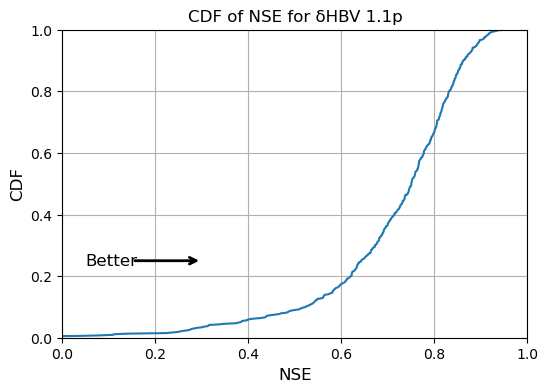

cleaned metric has # of basins 531


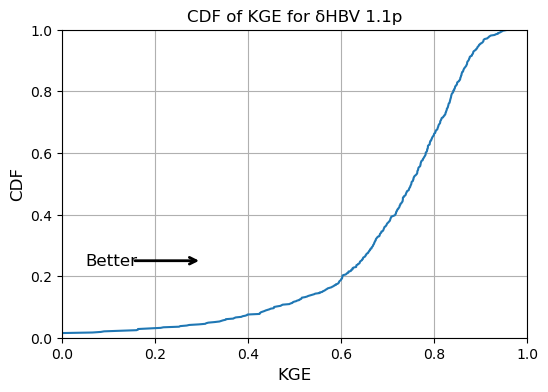

In [14]:
import importlib
import tempfunctions
importlib.reload(tempfunctions)
from tempfunctions import *

import importlib
from dmg.core import post
from dmg.core.post import plot_cdf
%matplotlib inline
#------------------------------------------#
# Choose the metric to plot. (See available metrics printed above, or in the metrics_agg.json file).
METRICS = ['nse', 'kge']

for METRIC in METRICS: 
    # 1. Load the evaluation metrics.
    metrics_path = os.path.join(config['output_dir'], 'metrics.json')
    metrics = load_json(metrics_path)
    metrics = cleannans(metrics, METRIC) ## double check why there are nans
    print("cleaned metric has # of basins", len(metrics[METRIC]))
    
    # 2. Plot the CDF.
    plot_cdf(
        metrics=[metrics],
        metric_names=[METRIC],
        model_labels=['δHBV 1.1p'],
        title=f"CDF of {METRIC.upper()} for δHBV 1.1p",
        xlabel=METRIC.upper(),
        figsize=(6, 4),
        xbounds=(0, 1),
        ybounds=(0, 1),
        show_arrow=True,
    )

#### 2.2.2 Spatial Plot

This plot shows the locations of each basin in the evaluation data, color-coded by performance on a metric. Here we give a plot for NSE, but as before, this can be changed to your preference. (See above; for metrics not valued between 0 and 1, you will need to set `dynamic_colorbar=True` in `geoplot_single_metric` to ensure proper coding.)

Note, you will need to add paths to the CAMELS shapefile, gage IDs, and 531-gage subset which can be found in the [CAMELS download](#before-running).

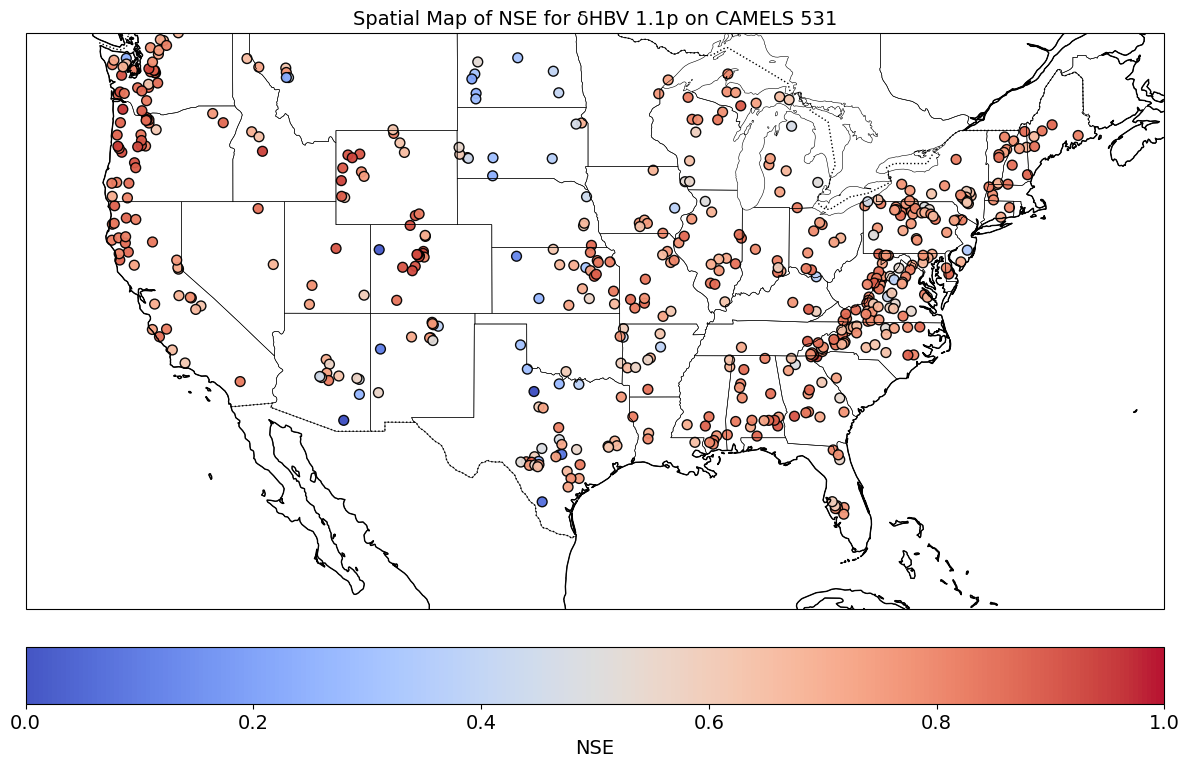

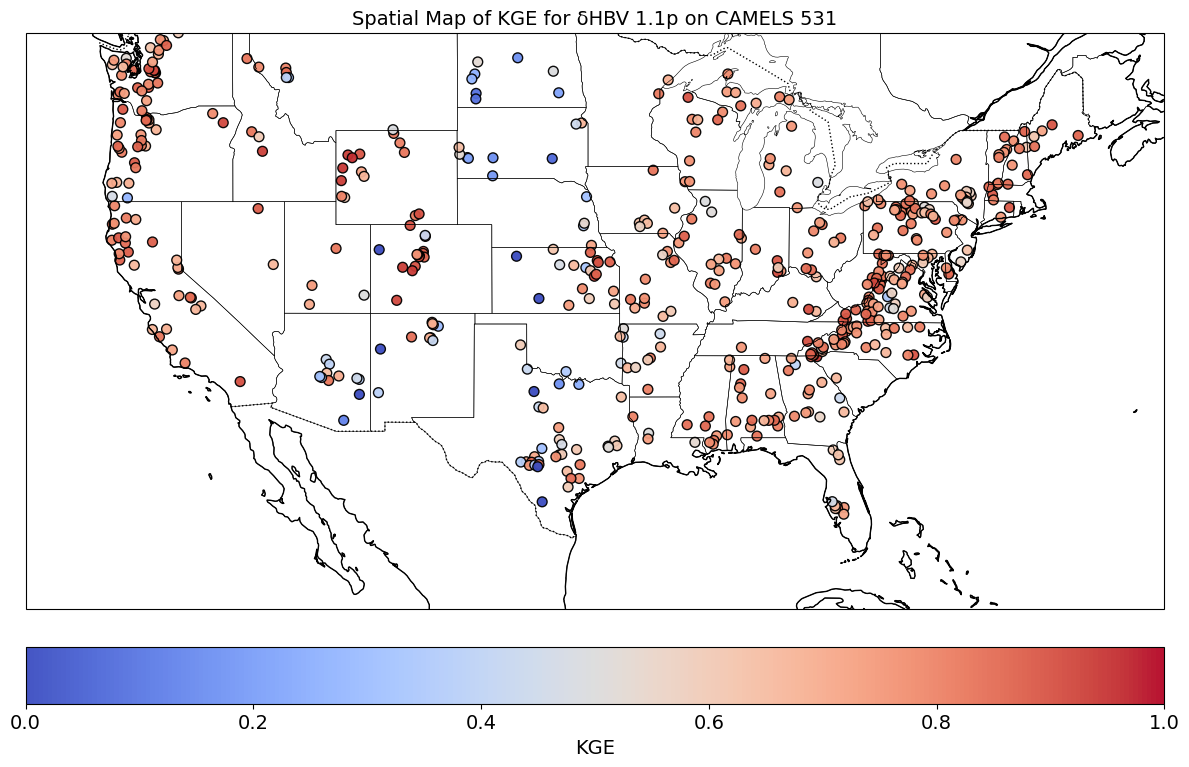

In [18]:
import geopandas as gpd
import numpy as np
import pandas as pd
from dmg.core.data import txt_to_array
from dmg.core.post import geoplot_single_metric
%matplotlib inline

for METRIC in METRICS:
    GAGE_ID_PATH = config['observations']['gage_info']  #./gage_id.npy
    GAGE_ID_531_PATH = config['observations']['subset_path']  #./531sub_id.txt
    SHAPEFILE_PATH = './predownloaded/camels_loc/camels_671_loc.shp' ## zhennan added to his directory

    # 1. Load gage ids + basin shapefile with geocoordinates (lat, long) for every gage.
    gage_ids = np.load(GAGE_ID_PATH, allow_pickle=True)
    gage_ids_subset = txt_to_array(GAGE_ID_531_PATH)
    coords = gpd.read_file(SHAPEFILE_PATH)

    # 2. Format geocoords for 531- and 671-basin CAMELS sets.
    coords_531 = coords[coords['gage_id'].isin(list(gage_ids_subset))].copy()

    coords['gage_id'] = pd.Categorical(coords['gage_id'], categories=list(gage_ids), ordered=True)
    coords_531['gage_id'] = pd.Categorical(coords_531['gage_id'], categories=list(gage_ids_subset), ordered=True)

    coords = coords.sort_values('gage_id')  # Sort to match order of metrics.
    basin_coords_531 = coords_531.sort_values('gage_id')

    # 3. Load the evaluation metrics.
    metrics_path = os.path.join(config['output_dir'], 'metrics.json')
    metrics = load_json(metrics_path)

    # 4. Add the evaluation metrics to the basin shapefile.
    if config['observations']['name'] == 'camels_671':
        coords[METRIC] = metrics[METRIC]
        full_data = coords
    elif config['observations']['name'] == 'camels_531':
        coords_531[METRIC] = metrics[METRIC]
        full_data = coords_531
    else:
        raise ValueError(f"Observation data supported: 'camels_671' or 'camels_531'. Got: {config['observations']}")

    # 5. Plot the evaluation results spatially.
    geoplot_single_metric(
        full_data,
        METRIC,
        save_path=f"{METRIC}_spatial_map.png",
        title=rf"Spatial Map of {METRIC.upper()} for δHBV 1.1p on CAMELS "
              f"{config['observations']['name'].split('_')[-1]}",
        dynamic_colorbar=False,
    )